In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import json
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = r"C:\Users\varke\OneDrive\Documents\My Folders\Project\automotive-complaint-nlp\data\FLAT_CMPL.txt"
OUTPUT_DIR = r"C:\Users\varke\OneDrive\Documents\My Folders\Project\automotive-complaint-nlp\outputs"
SAVE_DIR = r"C:\Users\varke\OneDrive\Documents\My Folders\Project\automotive-complaint-nlp\data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Imports done.")

Imports done.


## Loading the NHTSA dataset

The NHTSA complaints file is tab-separated with no column headers.
We verified the exact field positions from the raw file:
  - Index 11 → COMPDESC (component description — our TARGET)
  - Index 19 → CDESCR (complaint text — our INPUT)

Rather than loading all 51 columns and risking alignment errors,
we load only the two columns we need by position using usecols.
This is faster, uses less memory, and eliminates any column mismatch risk.

In [2]:
df = pd.read_csv(
    DATA_PATH,
    sep='\t',
    header=None,
    usecols=[3, 4, 5, 11, 19],
    names=['make', 'model', 'year', 'component', 'complaint'],
    encoding='latin-1',
    low_memory=False,
    on_bad_lines='skip'
)

print("Shape:", df.shape)
print("\nColumn check — first 3 rows:")
print(df.head(3))
print("\nMissing values:")
print(df.isnull().sum())

Shape: (2205657, 5)

Column check — first 3 rows:
    make        model    year  \
0  VOLVO          760  1987.0   
1   FORD  THUNDERBIRD  1992.0   
2    KIA       SEPHIA  1994.0   

                                           component  \
0  ENGINE AND ENGINE COOLING:COOLING SYSTEM:RADIA...   
1                     FUEL SYSTEM, GASOLINE:DELIVERY   
2                 POWER TRAIN:AUTOMATIC TRANSMISSION   

                                           complaint  
0  RADIATOR FAILED @ HIGHWAY SPEED OBSTRUCTING DR...  
1  FUEL LEAKED FROM FUEL TANK AREA, EMITTING STRO...  
2  SHIFTED INTO REVERSE VEHICLE JERKED VIOLENTLY....  

Missing values:
make          24
model         26
year          24
component    149
complaint     99
dtype: int64


In [3]:
df = df.dropna(subset=['component', 'complaint'])
df = df[df['complaint'].str.strip() != '']
df = df[df['component'].str.strip() != '']

print("Shape after dropping nulls:", df.shape)
print("\nSample component values:")
print(df['component'].head(5).tolist())

Shape after dropping nulls: (2205406, 5)

Sample component values:
['ENGINE AND ENGINE COOLING:COOLING SYSTEM:RADIATOR ASSEMBLY', 'FUEL SYSTEM, GASOLINE:DELIVERY', 'POWER TRAIN:AUTOMATIC TRANSMISSION', 'FUEL SYSTEM, GASOLINE:STORAGE:TANK ASSEMBLY', 'SEATS']


## Understanding the component field

The COMPDESC field uses colons to represent a hierarchy:

  ENGINE AND ENGINE COOLING:COOLING SYSTEM:RADIATOR ASSEMBLY
  SERVICE BRAKES:HYDRAULIC:ANTILOCK
  POWER TRAIN:AUTOMATIC TRANSMISSION

The top-level category (before the first colon) is what we classify.
We extract this by splitting on ':' and taking the first part.
This handles all subcategory variations automatically.

In [4]:
df['top_component'] = df['component'].str.split(':').str[0].str.strip().str.upper()

print("Total unique top-level components:", df['top_component'].nunique())
print("\nTop 30 most common:")
print(df['top_component'].value_counts().head(30))

Total unique top-level components: 54

Top 30 most common:
top_component
ELECTRICAL SYSTEM                     243719
POWER TRAIN                           214068
ENGINE                                163456
AIR BAGS                              155504
STEERING                              142256
ENGINE AND ENGINE COOLING             120711
UNKNOWN OR OTHER                      113908
SERVICE BRAKES, HYDRAULIC             106793
STRUCTURE                             103085
SUSPENSION                             89140
VEHICLE SPEED CONTROL                  84324
TIRES                                  80628
SERVICE BRAKES                         76998
EXTERIOR LIGHTING                      62382
FUEL/PROPULSION SYSTEM                 60452
FUEL SYSTEM, GASOLINE                  55909
VISIBILITY                             53007
SEAT BELTS                             38770
EQUIPMENT                              32962
SEATS                                  28420
FORWARD COLLISION AVOIDANCE

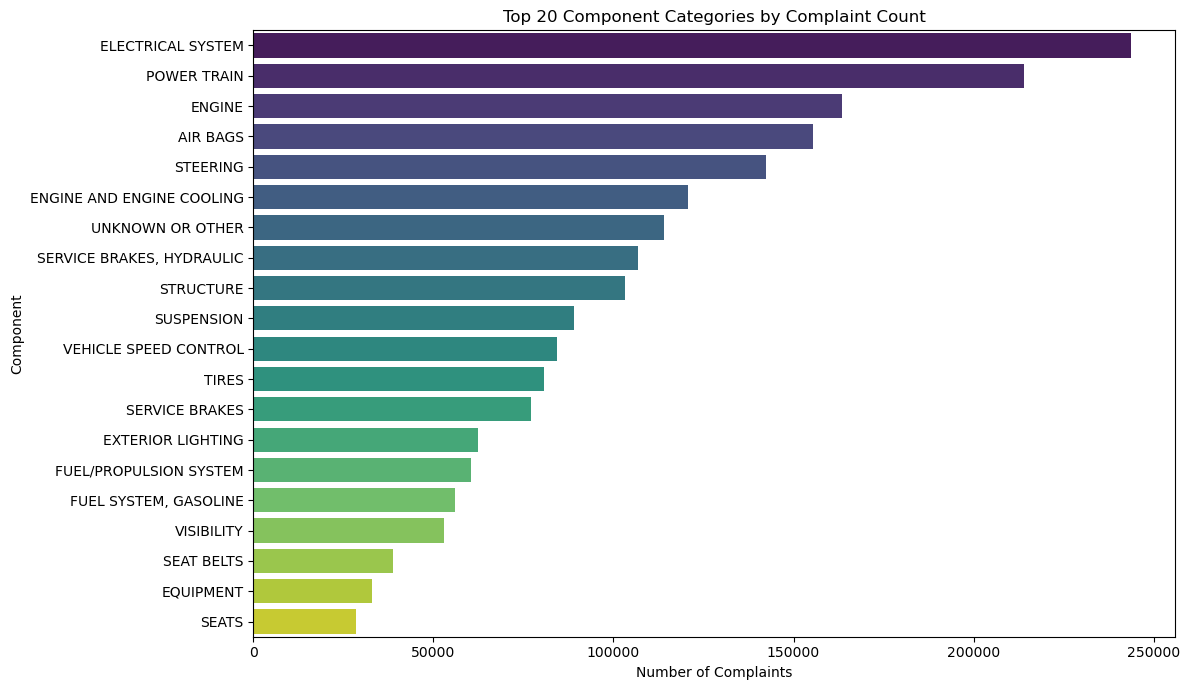


Top 20 categories cover 91.9% of all complaints


In [5]:
top20 = df['top_component'].value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=top20.values, y=top20.index, palette='viridis')
plt.title('Top 20 Component Categories by Complaint Count')
plt.xlabel('Number of Complaints')
plt.ylabel('Component')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'component_distribution.png'), dpi=150)
plt.show()

print(f"\nTop 20 categories cover {top20.sum() / len(df) * 100:.1f}% of all complaints")

## Selecting our 6 target categories

We select 6 safety-critical categories that:
1. Have large enough sample counts to train a strong classifier
2. Are semantically distinct — different vocabulary, different failure modes
3. Cover the most important automotive safety systems

Selected categories:
1. ENGINE AND ENGINE COOLING
2. SERVICE BRAKES
3. ELECTRICAL SYSTEM
4. STEERING
5. POWER TRAIN
6. AIR BAGS

In [6]:
target_categories = [
    'ENGINE AND ENGINE COOLING',
    'SERVICE BRAKES',
    'ELECTRICAL SYSTEM',
    'STEERING',
    'POWER TRAIN',
    'AIR BAGS'
]

print("Row counts for each target category:")
for cat in target_categories:
    count = (df['top_component'] == cat).sum()
    print(f"  '{cat}': {count:,} rows")

Row counts for each target category:
  'ENGINE AND ENGINE COOLING': 120,711 rows
  'SERVICE BRAKES': 76,998 rows
  'ELECTRICAL SYSTEM': 243,719 rows
  'STEERING': 142,256 rows
  'POWER TRAIN': 214,068 rows
  'AIR BAGS': 155,504 rows


In [7]:
category_map = {
    'ENGINE AND ENGINE COOLING': 'ENGINE',
    'SERVICE BRAKES': 'BRAKES',
    'ELECTRICAL SYSTEM': 'ELECTRICAL',
    'STEERING': 'STEERING',
    'POWER TRAIN': 'POWERTRAIN',
    'AIR BAGS': 'AIRBAGS',
}

df_filtered = df[df['top_component'].isin(target_categories)].copy()
df_filtered['label'] = df_filtered['top_component'].map(category_map)

print("Shape after filtering:", df_filtered.shape)
print("\nClass distribution:")
print(df_filtered['label'].value_counts())

Shape after filtering: (953256, 7)

Class distribution:
label
ELECTRICAL    243719
POWERTRAIN    214068
AIRBAGS       155504
STEERING      142256
ENGINE        120711
BRAKES         76998
Name: count, dtype: int64


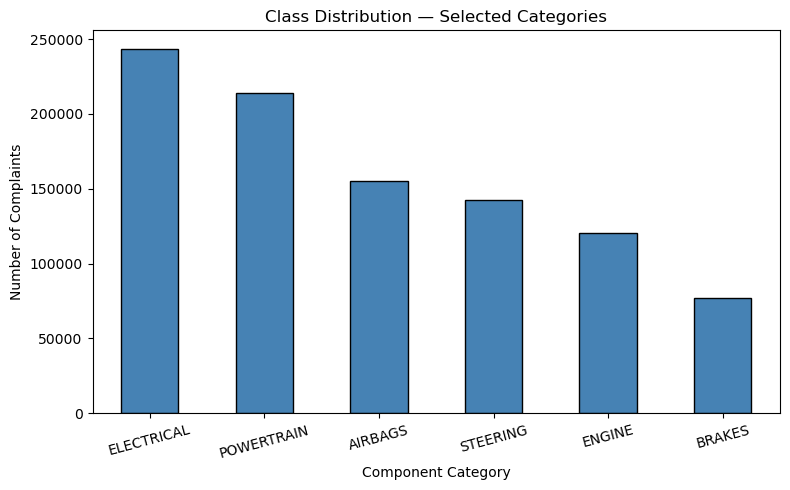

In [8]:
plt.figure(figsize=(8, 5))
df_filtered['label'].value_counts().plot(
    kind='bar', color='steelblue', edgecolor='black'
)
plt.title('Class Distribution — Selected Categories')
plt.xlabel('Component Category')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=150)
plt.show()

In [9]:
for label in sorted(df_filtered['label'].unique()):
    print(f"\n{'='*60}")
    print(f"Category: {label}")
    print('='*60)
    samples = df_filtered[df_filtered['label'] == label]['complaint'].head(2)
    for i, s in enumerate(samples, 1):
        print(f"\nSample {i}:")
        print(str(s)[:400])


Category: AIRBAGS

Sample 1:
AIR BAG; THREE TIMES IN DEALERSHIP FOR SRS SIGNAL CONTINUOUSLY ILLUMINATING. ZONE REP ALSO CAME TO INVESTIGATE WHY LIGHT STAYS ON. PLEASE DESCRIBE DETAILS.  TT

Sample 2:
UPON IMPACT, DURING FRONTAL CRASH AT APPROX. 10 MPH, 2:00 ON FRONT BUMPER, DRIVERS/PASSENGERS AIRBAGS FAILED TO DEPLOY, RESULTING IN INJURY.   TT

Category: BRAKES

Sample 1:
WE PURCHASED TWO NEW TOWNCARS FROM GERMAIN LINC.-MERC., NAPLES, FL, IN 1999 AND 2000 MY CAR'S,VIN [XXX], 1999 TOWN CAR, AND MY WIFE'S 2000 TOWN CAR, VIN [XXX].  MY FIRST COMPLAINT IS REGARDING MY CAR THAT DEVELOPED ELECTRONIC PROBLEMS RIGHT AFTER IT RAN OUT OF WARRANTY, AND NEEDED A $500 REPAIR. A WEEK LATER, IT DEVELOPED A LEAK, AND WAS REPAIRED AT $1000. IS THIS PLANNED OBSOLESCENCE? THIS WAS AT

Sample 2:
IN PAST MONTH LINCOLN LS 2002 VIN [XXX] EXPERIENCED TWO LOW-SPEED (LESS THAN 10 MPH) BRAKE FAILURES.ONE RESULTED IN A MINOR ACCIDENT.THE FIRST OCCURRED APPROX. MAY 1, BUT NO ACCIDENT RESULTED.WHILE I WAS ATTEMPTI

## Text cleaning

Raw NHTSA complaint text needs cleaning:
- ALL CAPS (old system — typed on early terminals)
- Asterisks used as separators
- Investigator codes appended at the end (e.g. *AK, TT)
- Extra whitespace and special characters

We do NOT remove stopwords (the, is, was).
DistilBERT understands full sentence context and
benefits from stopwords being present.
We also do NOT stem or lemmatize — DistilBERT handles
word forms natively through its tokenizer.

In [10]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\*+[a-z]{0,2}\s*$', '', text)
    text = re.sub(r'\*+', ' ', text)
    text = re.sub(r'\btt\b|\bak\b', '', text)
    text = re.sub(r'[^a-z0-9\s.,!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_filtered['clean_complaint'] = df_filtered['complaint'].apply(clean_text)

df_filtered = df_filtered[
    df_filtered['clean_complaint'].str.split().str.len() >= 10
].copy()

print("Shape after cleaning:", df_filtered.shape)
print("\nBefore cleaning:")
print(df_filtered['complaint'].iloc[0][:300])
print("\nAfter cleaning:")
print(df_filtered['clean_complaint'].iloc[0][:300])

Shape after cleaning: (903980, 8)

Before cleaning:
RADIATOR FAILED @ HIGHWAY SPEED OBSTRUCTING DRIVERS VISION TEMPORARY. PLEASE DESCRIBE DETAILS.  TT

After cleaning:
radiator failed highway speed obstructing drivers vision temporary. please describe details.


Word count statistics:
count    903980.0
mean         97.0
std          79.0
min          10.0
25%          43.0
50%          76.0
75%         124.0
max        8866.0
Name: word_count, dtype: float64


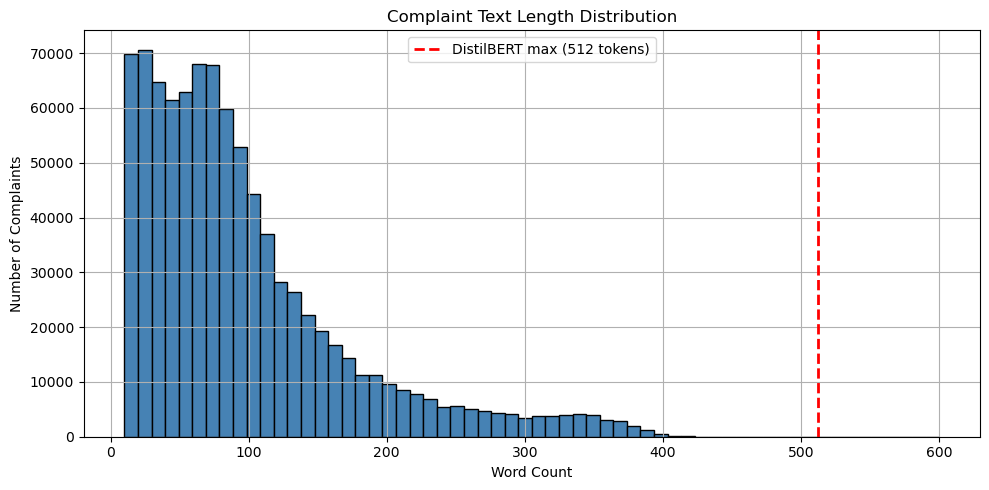


Complaints over 512 words: 0.0%


In [11]:
df_filtered['word_count'] = df_filtered['clean_complaint'].apply(
    lambda x: len(x.split())
)

print("Word count statistics:")
print(df_filtered['word_count'].describe().round(0))

plt.figure(figsize=(10, 5))
df_filtered['word_count'].clip(upper=600).hist(
    bins=60, color='steelblue', edgecolor='black'
)
plt.axvline(x=512, color='red', linestyle='--',
            linewidth=2, label='DistilBERT max (512 tokens)')
plt.title('Complaint Text Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Number of Complaints')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'text_length_distribution.png'), dpi=150)
plt.show()

pct_over = (df_filtered['word_count'] > 512).mean() * 100
print(f"\nComplaints over 512 words: {pct_over:.1f}%")

In [12]:
min_count = df_filtered['label'].value_counts().min()
sample_size = min(3000, min_count)

print(f"Smallest class has: {min_count:,} samples")
print(f"Sampling {sample_size} per class")

sampled_parts = []
for label in df_filtered['label'].unique():
    part = df_filtered[df_filtered['label'] == label].sample(
        sample_size, random_state=42
    )
    sampled_parts.append(part)

df_sampled = pd.concat(sampled_parts).reset_index(drop=True)

print(f"\nFinal dataset shape: {df_sampled.shape}")
print("\nClass distribution after sampling:")
print(df_sampled['label'].value_counts())

Smallest class has: 75,409 samples
Sampling 3000 per class

Final dataset shape: (18000, 9)

Class distribution after sampling:
label
ENGINE        3000
POWERTRAIN    3000
AIRBAGS       3000
STEERING      3000
ELECTRICAL    3000
BRAKES        3000
Name: count, dtype: int64


In [13]:
label_list = sorted(df_sampled['label'].unique())
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {str(idx): label for label, idx in label2id.items()}

df_sampled['label_id'] = df_sampled['label'].map(label2id)

print("Label encoding:")
for label, idx in label2id.items():
    count = (df_sampled['label'] == label).sum()
    print(f"  {label} → {idx}  ({count} samples)")

print(f"\nFinal dataframe shape: {df_sampled.shape}")
print("\nSample:")
print(df_sampled[['clean_complaint', 'label', 'label_id']].head(3))

Label encoding:
  AIRBAGS → 0  (3000 samples)
  BRAKES → 1  (3000 samples)
  ELECTRICAL → 2  (3000 samples)
  ENGINE → 3  (3000 samples)
  POWERTRAIN → 4  (3000 samples)
  STEERING → 5  (3000 samples)

Final dataframe shape: (18000, 10)

Sample:
                                     clean_complaint   label  label_id
0  consumer states that while driving at any spee...  ENGINE         3
1  2001 ford excursion 5.4l triton v8. at 89,000 ...  ENGINE         3
2  2006 nissan pathfinder in august the fuel gaug...  ENGINE         3


In [14]:
df_sampled[['clean_complaint', 'label', 'label_id']].to_csv(
    os.path.join(SAVE_DIR, 'complaints_clean.csv'), index=False
)

with open(os.path.join(SAVE_DIR, 'label_mapping.json'), 'w') as f:
    json.dump({'label2id': label2id, 'id2label': id2label}, f, indent=2)

print(f"Saved complaints_clean.csv — {df_sampled.shape[0]:,} rows")
print(f"Saved label_mapping.json — {len(label2id)} classes")
print(f"\nClasses: {label_list}")
print(f"Outputs saved to: {OUTPUT_DIR}")

Saved complaints_clean.csv — 18,000 rows
Saved label_mapping.json — 6 classes

Classes: ['AIRBAGS', 'BRAKES', 'ELECTRICAL', 'ENGINE', 'POWERTRAIN', 'STEERING']
Outputs saved to: C:\Users\varke\OneDrive\Documents\My Folders\Project\automotive-complaint-nlp\outputs


## Summary

1. Loaded NHTSA complaints using exact column positions (verified from raw file)
   - Index 11 = COMPDESC (component label)
   - Index 19 = CDESCR (complaint text)
2. Extracted top-level component by splitting on colon separator
3. Selected 6 safety-critical categories: ENGINE, BRAKES, ELECTRICAL,
   STEERING, POWERTRAIN, AIRBAGS
4. Cleaned complaint text: lowercase, removed special characters, 
   stripped NHTSA investigator codes
5. Dropped complaints under 10 words
6. Checked text lengths vs DistilBERT 512 token limit
7. Balanced dataset: sampled equally across all 6 classes
8. Encoded labels as integers for DistilBERT training
9. Saved clean CSV and label mapping JSON

Next: Fine-tune DistilBERT on Google Colab